# Attention matrix tasks

In this notebook we will perform some tasks on the attention matrix computed in the previous notebook, in order to explore the information flow between cell labesl and spatial location using the molecular cartography dataset used from [Legnini et al., 2023](https://doi.org/10.1038/s41592-023-01986-w) which we preprocessed in the [previous tutorial](./1_model_training.ipynb)

**Requirements**:

- Inference results in the anndata object
- Trained model to load inference results

## Import Packages

In [47]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import seaborn as sns
import random
import torch

from pathlib import Path

In [48]:
def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



set_full_reproducibility(42)

In [ ]:
import interscale as interscale
from interscale.config import load_config
import scanpy as sc

In [ ]:

from interscale.evaluation.net_streams import cluster_spatial_flows
from interscale.evaluation.net_streams import map_clusters_to_cells
from InterScale.evaluation.net_streams import compute_hierarchical_net_flow, plot_global_directionality
from InterScale.evaluation.net_streams import plot_all_spatial_net_streams
from interscale.evaluation.net_streams import characterize_flow_clusters
from scipy.ndimage import gaussian_filter

In [ ]:
import sys

# Find repo root by locating paths.py
BASE_DIR_PROJECT = Path.cwd().resolve().parent.parent

sys.path.insert(0, str(BASE_DIR_PROJECT))
DATA = "legnini"
RESULTS_DIR = Path(f"{BASE_DIR_PROJECT}/results/{DATA}")

## Load Data and Model

To load the model, check in the previous tutorial [1_model_training.ipynb](1_model_training.ipynb) in the model training for the path where the model was saved to. 

In [ ]:
adata = sc.read_h5ad(f"{BASE_DIR_PROJECT}/data/{DATA}_trained.h5ad")
cfg = load_config(Path(f"{BASE_DIR_PROJECT}/config_files/{DATA}_example.yaml"))

In [ ]:
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs = cfg.dataset.prediction_obs)


In [ ]:
model= interscale.model.CombinedModel(
	adata,
	cfg = cfg
)


model=model.load(adata=adata,cfg=cfg,dir_path=os.path.join(RESULTS_DIR),global_component=True,local_component=True)

Loading model from /beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/prove_interscale/model/dual_legnini23nrec_regr_node_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/idle/ric.cirillo/dimarco.federico/envs/Interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [16]:
set_full_reproducibility(42)
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm


## Attention matrix tasks

First we will compute for each cell label the net flow of information to other cell labels by computing a hierarchical net flow from the attention matrix produced by the model.

/beegfs/scratch/ric.cirillo/dimarco.federico/PHD_gnn/INTERACTION/GT-long-range-niches/src/InterScale/evaluation/net_streams.py:433: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_to_wins = adata.obs.groupby(sample_key)[window_key].unique()


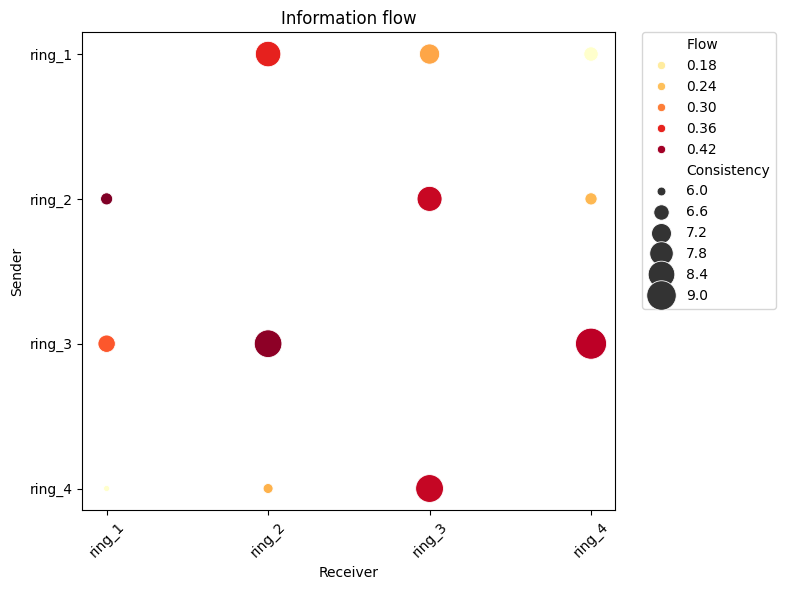

In [ ]:
res=compute_hierarchical_net_flow(result,sample_key='sample',cell_type_col='SHH_cats',compute_net=False)

plot_global_directionality(res['all_samples']['mean'], res['all_samples']['std'], only_positive=True, title="Information flow",figsize=(8, 6))

## Net flow spatial visualization

We can also visualize the net flow of information spatially by plotting the net flow for each cell in the spatial coordinates.

In [21]:
result.uns['SHH_cats']=['#028e95','#f56d18','#ff0000','#25e907']
result.obs['SHH_cats'].cat.categories

Index(['ring_1', 'ring_2', 'ring_3', 'ring_4'], dtype='object')

In [22]:
cell_type_col='SHH_cats'
cell_list=['ring_1','ring_2','ring_3','ring_4']
categories = list(result.obs[cell_type_col].cat.categories)
if cell_list is not None:
	categories = [cat for cat in categories if cat in cell_list]
if f'{cell_type_col}_colors' in result.uns:
	colors = list(result.uns[f'{cell_type_col}_colors'])
	if cell_list is not None:
		colors = [color for cat, color in zip(result.obs[cell_type_col].cat.categories, colors) if cat in cell_list]
	color_map = dict(zip(categories, colors))

In [23]:
color_map

colors = [color for cat, color in zip(result.obs[cell_type_col].cat.categories, colors) if cat in cell_list]

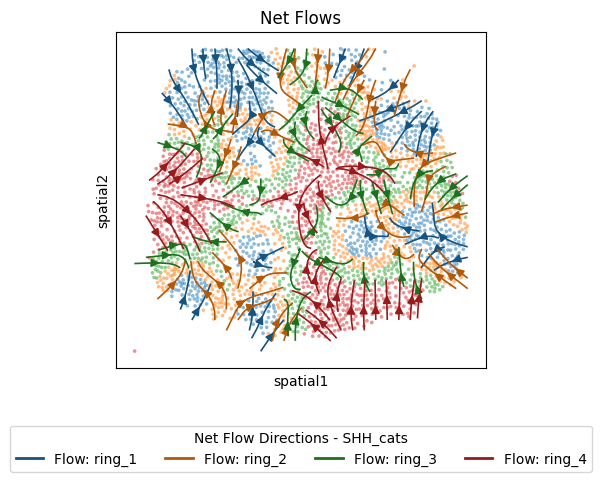

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
result.obs['dummy']=result.obs[cell_type_col].apply(lambda x: x if x in cell_list else 'Other').astype('category')

colors = list(result.uns[f'{cell_type_col}_colors'])
colors = [color for cat, color in zip(result.obs[cell_type_col].cat.categories, colors) if cat in cell_list]




result.uns['dummy_colors']=colors

plot_all_spatial_net_streams(result, fov_id='slide1_A2-1',fov_key='sample',
							window_key='sample',
							#additional_embeddings='dummy',
							k_dist=0.08,density=1,size=40,
							ax=ax,title=f'Net Flows',
							inter_only=True,
	cell_type_col=cell_type_col,alpha=0.5,cell_list=cell_list)


plt.tight_layout()


## Clustering Spatial flows

Finally, we identify functional spatial domains (or niches) by clustering the multi-type net flow signatures. For each point in the spatial grid, we aggregate the divergence and magnitude of the net flow for every cell label, using these as features for unsupervised clustering.

These grid-level cluster assignments are then mapped back to individual cells using a nearest-neighbor approach. To interpret the biological role of these domains, we compute the average divergence of each cell type within each cluster, categorizing them as sources or sinks of information based on whether they significantly contribute to or absorb the local interaction flow.

In [32]:
streams, X_lin,Y_lin=plot_all_spatial_net_streams(result, fov_id='slide1_A2-1',fov_key='sample',
							window_key='sample',
							#additional_embeddings='dummy',
							k_dist=0.08,density=1,size=40,
							ax=ax,title=f'Net Flows',
							inter_only=True,
	cell_type_col=cell_type_col,alpha=0.5,return_streams=True)

In [ ]:
sigma_smooth = 3 
U_dict = {cat: gaussian_filter(v[0], sigma=sigma_smooth) for cat, v in streams.items()}
V_dict = {cat: gaussian_filter(v[1], sigma=sigma_smooth) for cat, v in streams.items()}
a,b=cluster_spatial_flows(U_dict , V_dict, n_clusters=6)



In [41]:
c=map_clusters_to_cells(a, X_lin, Y_lin, result, fov_id='slide1_A2-1',fov_key='sample')

In [ ]:
characterize_flow_clusters(U_dict, V_dict, a)

,cell_type,cluster_id,avg_divergence,role
0,ring_1,0,0.654122,Source
1,ring_1,1,-0.260281,Neutral
2,ring_1,2,-0.087279,Neutral
3,ring_1,3,-0.699110,Sink
4,ring_1,4,0.275452,Neutral
5,ring_1,5,-0.421129,Neutral
6,ring_2,0,-0.477310,Neutral
7,ring_2,1,0.523190,Source
8,ring_2,2,-0.215359,Neutral
9,ring_2,3,-0.381000,Neutral
